# Decision Tree from Scratch — Play Tennis Masterclass

This executed notebook derives the complete categorical ID3 tree by hand and then implements the same learner from first principles. No ready-made decision-tree estimator is used.

## Learning map

**class counts → class probabilities → node impurity → candidate partitions → weighted child impurity → impurity reduction → best split → recursion → leaf rules → inference**

### Tree vocabulary

- **Root:** first question applied to all rows.
- **Internal node:** question applied only to the subset arriving there.
- **Branch:** an answer/category of the split feature.
- **Leaf:** terminal prediction.
- **Pure node:** all rows have one class; impurity is zero.
- **Recursive partitioning:** repeat the same split search inside each impure child.
- **Greedy search:** choose the best immediate split; the globally optimal tree is not exhaustively searched.

The target is $Y=PlayTennis\in\{Yes,No\}$. Predictors are `Outlook`, `Temperature`, `Humidity`, and `Wind`. `Day` is an identifier and must not be used: a high-cardinality ID can create one-row leaves and overfit.

## Splitting criteria

For a node $S$ with class proportions $p_k=n_k/|S|$:

$$H(S)=-\sum_k p_k\log_2p_k,\qquad 0\log_2 0:=0$$

$$Gini(S)=1-\sum_kp_k^2$$

$$Error(S)=1-\max_kp_k$$

For feature $A$ and child subsets $S_v$:

$$I(S\mid A)=\sum_{v\in Values(A)}\frac{|S_v|}{|S|}I(S_v)$$

$$Gain_I(S,A)=I(S)-I(S\mid A)$$

Weighting is mandatory: a child containing ten observations must influence the split more than a child containing one.

## Parent entropy — manual calculation

The dataset has $9$ Yes and $5$ No:

$$H(S)=-\frac9{14}\log_2\frac9{14}-\frac5{14}\log_2\frac5{14}=\boxed{0.940286}$$

## Every candidate root split — manual calculation

### Outlook

Sunny $=(2Y,3N),H=0.970951$; Overcast $=(4Y,0N),H=0$; Rain $=(3Y,2N),H=0.970951$.

$$H(S\mid Outlook)=\frac5{14}(0.970951)+\frac4{14}(0)+\frac5{14}(0.970951)=0.693536$$
$$IG(S,Outlook)=0.940286-0.693536=\boxed{0.246750}$$

### Temperature

Hot $=(2Y,2N),H=1$; Mild $=(4Y,2N),H=0.918296$; Cool $=(3Y,1N),H=0.811278$.

$$H(S\mid Temperature)=\frac4{14}(1)+\frac6{14}(0.918296)+\frac4{14}(0.811278)=0.911063$$
$$IG(S,Temperature)=\boxed{0.029223}$$

### Humidity

High $=(3Y,4N),H=0.985228$; Normal $=(6Y,1N),H=0.591673$.

$$H(S\mid Humidity)=\frac7{14}(0.985228)+\frac7{14}(0.591673)=0.788450$$
$$IG(S,Humidity)=\boxed{0.151836}$$

### Wind

Weak $=(6Y,2N),H=0.811278$; Strong $=(3Y,3N),H=1$.

$$H(S\mid Wind)=\frac8{14}(0.811278)+\frac6{14}(1)=0.892159$$
$$IG(S,Wind)=\boxed{0.048127}$$

Hence $\boxed{Root=Outlook}$ because it produces the largest entropy reduction.


In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH = Path("data/play_tennis.csv")
df = pd.read_csv(DATA_PATH)
FEATURES = ["Outlook", "Temperature", "Humidity", "Wind"]
TARGET = "PlayTennis"
print(f"Shape: {df.shape}")
display(df)
print("Target counts:")
display(df[TARGET].value_counts().rename_axis("Class").to_frame("Count"))


Shape: (14, 6)


    Day   Outlook Temperature Humidity    Wind PlayTennis
0    D1     Sunny         Hot     High    Weak         No
1    D2     Sunny         Hot     High  Strong         No
2    D3  Overcast         Hot     High    Weak        Yes
3    D4      Rain        Mild     High    Weak        Yes
4    D5      Rain        Cool   Normal    Weak        Yes
5    D6      Rain        Cool   Normal  Strong         No
6    D7  Overcast        Cool   Normal  Strong        Yes
7    D8     Sunny        Mild     High    Weak         No
8    D9     Sunny        Cool   Normal    Weak        Yes
9   D10      Rain        Mild   Normal    Weak        Yes
10  D11     Sunny        Mild   Normal  Strong        Yes
11  D12  Overcast        Mild     High  Strong        Yes
12  D13  Overcast         Hot   Normal    Weak        Yes
13  D14      Rain        Mild     High  Strong         No

Target counts:


       Count
Class       
Yes        9
No         5

In [2]:
def probabilities(labels):
    counts = pd.Series(labels).value_counts().to_numpy(dtype=float)
    return counts / counts.sum()

def entropy(labels):
    p = probabilities(labels)
    return float(-np.sum(p * np.log2(p)))

def gini(labels):
    p = probabilities(labels)
    return float(1 - np.sum(p ** 2))

def weighted_impurity(data, feature, criterion=entropy):
    total = len(data)
    return sum((len(part) / total) * criterion(part[TARGET])
               for _, part in data.groupby(feature, observed=True))

def split_report(data, features, criterion=entropy):
    parent = criterion(data[TARGET])
    rows = []
    for feature in features:
        child = weighted_impurity(data, feature, criterion)
        rows.append((feature, parent, child, parent-child))
    return pd.DataFrame(rows, columns=["Feature","Parent impurity","Weighted child impurity","Information gain"]).sort_values("Information gain", ascending=False)

parent_h = entropy(df[TARGET])
print(f"Parent entropy = {parent_h:.6f}")
root_report = split_report(df, FEATURES)
display(root_report.style.format(precision=6))
assert root_report.iloc[0]["Feature"] == "Outlook"


Parent entropy = 0.940286


Feature      Parent     Weighted child   Information gain
Outlook      0.940286   0.693536         0.246750
Humidity     0.940286   0.788450         0.151836
Wind         0.940286   0.892159         0.048127
Temperature  0.940286   0.911063         0.029223

## Recursive derivation after selecting Outlook

### Outlook = Overcast

The subset is $(4Y,0N)$, so $H=0$. It is immediately a `Yes` leaf.

### Outlook = Sunny

Sunny is $(2Y,3N)$:

$$H(Sunny)=-\frac25\log_2\frac25-\frac35\log_2\frac35=0.970951$$

- Humidity: High $=(0Y,3N)$ and Normal $=(2Y,0N)$, so weighted entropy $=0$ and gain $=\boxed{0.970951}$.
- Temperature: Hot $=(0Y,2N)$, Mild $=(1Y,1N)$, Cool $=(1Y,0N)$; weighted entropy $=0.4$, gain $=0.570951$.
- Wind: Weak $=(1Y,2N)$, Strong $=(1Y,1N)$; weighted entropy $=0.950978$, gain $=0.019973$.

Therefore $\boxed{Sunny\rightarrow Humidity}$: High $\rightarrow No$, Normal $\rightarrow Yes$.

### Outlook = Rain

Rain is $(3Y,2N)$, so $H(Rain)=0.970951$.

- Wind: Weak $=(3Y,0N)$ and Strong $=(0Y,2N)$; weighted entropy $=0$, gain $=\boxed{0.970951}$.
- Temperature: weighted entropy $=0.950978$, gain $=0.019973$.
- Humidity: weighted entropy $=0.950978$, gain $=0.019973$.

Therefore $\boxed{Rain\rightarrow Wind}$: Weak $\rightarrow Yes$, Strong $\rightarrow No$.

## Final rules

1. IF Outlook = Overcast THEN Yes.
2. IF Outlook = Sunny AND Humidity = High THEN No.
3. IF Outlook = Sunny AND Humidity = Normal THEN Yes.
4. IF Outlook = Rain AND Wind = Weak THEN Yes.
5. IF Outlook = Rain AND Wind = Strong THEN No.


Sunny candidate splits


Feature      Sunny gain
Humidity     0.970951
Temperature  0.570951
Wind         0.019973

Rain candidate splits


Feature      Rain gain
Wind         0.970951
Humidity     0.019973
Temperature  0.019973

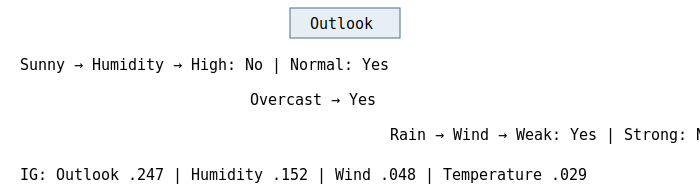

In [3]:
sunny = df[df.Outlook.eq("Sunny")]
rain = df[df.Outlook.eq("Rain")]
print("Sunny candidate splits")
display(split_report(sunny, ["Temperature","Humidity","Wind"]).style.format(precision=6))
print("Rain candidate splits")
display(split_report(rain, ["Temperature","Humidity","Wind"]).style.format(precision=6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=root_report, x="Feature", y="Information gain", ax=axes[0], color="#4f6d8a")
axes[0].set_title("Root information gain")
axes[0].axhline(0, color="black", linewidth=.8)
axes[1].axis("off")
axes[1].text(.5,.5,"Outlook\n├─ Overcast → Yes\n├─ Sunny → Humidity\n│  ├─ High → No\n│  └─ Normal → Yes\n└─ Rain → Wind\n   ├─ Weak → Yes\n   └─ Strong → No",ha="center",va="center",family="monospace",fontsize=13)
axes[1].set_title("Final learned tree")
plt.tight_layout()
plt.show()


## Complete categorical ID3 implementation from first principles

The learner carries the current subset, remaining features, depth, node majority fallback, and stopping rules. It never calls `sklearn.tree`.

In [4]:
from dataclasses import dataclass, field

@dataclass
class TreeNode:
    prediction: str
    feature: str | None = None
    gain: float = 0.0
    depth: int = 0
    children: dict = field(default_factory=dict)
    counts: dict = field(default_factory=dict)

    @property
    def is_leaf(self):
        return self.feature is None

class ID3DecisionTreeFromScratch:
    def __init__(self, max_depth=None, min_samples_split=2, min_gain=1e-12):
        self.max_depth=max_depth
        self.min_samples_split=min_samples_split
        self.min_gain=min_gain

    @staticmethod
    def majority(labels):
        # deterministic tie-break: count descending, class name ascending
        counts = pd.Series(labels).value_counts()
        return sorted(counts.index, key=lambda c: (-counts[c], str(c)))[0]

    def fit(self, data, features, target):
        self.features=list(features); self.target=target
        self.root_=self._grow(data.reset_index(drop=True), self.features, 0)
        return self

    def _grow(self, data, features, depth):
        counts=data[self.target].value_counts().to_dict()
        prediction=self.majority(data[self.target])
        node=TreeNode(prediction=prediction, depth=depth, counts=counts)
        pure=data[self.target].nunique()==1
        depth_stop=self.max_depth is not None and depth>=self.max_depth
        if pure or not features or depth_stop or len(data)<self.min_samples_split:
            return node
        report=split_report(data, features)
        best=report.iloc[0]
        if best["Information gain"] <= self.min_gain:
            return node
        node.feature=str(best["Feature"]); node.gain=float(best["Information gain"])
        remaining=[f for f in features if f != node.feature]
        for value, subset in data.groupby(node.feature, observed=True, sort=True):
            node.children[value]=self._grow(subset.drop(columns=[]), remaining, depth+1)
        return node

    def predict_one(self, row, trace=False):
        node=self.root_; path=[]
        while not node.is_leaf:
            value=row[node.feature]; path.append(f"{node.feature}={value}")
            if value not in node.children: # unseen category fallback
                path.append(f"unseen → majority={node.prediction}")
                return (node.prediction,path) if trace else node.prediction
            node=node.children[value]
        path.append(f"leaf={node.prediction}")
        return (node.prediction,path) if trace else node.prediction

    def predict(self, data):
        return pd.Series([self.predict_one(r) for _,r in data.iterrows()], index=data.index)

    def print_tree(self, node=None, prefix=""):
        node=self.root_ if node is None else node
        if node.is_leaf:
            print(prefix+f"Predict {node.prediction} | counts={node.counts}"); return
        print(prefix+f"Split {node.feature} | gain={node.gain:.6f} | counts={node.counts}")
        for value, child in node.children.items():
            print(prefix+f"  [{value}]")
            self.print_tree(child, prefix+"    ")

model=ID3DecisionTreeFromScratch().fit(df, FEATURES, TARGET)
model.print_tree()
pred=model.predict(df)
print(f"Training reconstruction accuracy: {(pred==df[TARGET]).mean():.1%}")
assert (pred==df[TARGET]).all()


Split Outlook | gain=0.246750 | counts={'Yes': 9, 'No': 5}
  [Overcast]
    Predict Yes | counts={'Yes': 4}
  [Rain]
    Split Wind | gain=0.970951 | counts={'Yes': 3, 'No': 2}
      [Strong]
        Predict No | counts={'No': 2}
      [Weak]
        Predict Yes | counts={'Yes': 3}
  [Sunny]
    Split Humidity | gain=0.970951 | counts={'No': 3, 'Yes': 2}
      [High]
        Predict No | counts={'No': 3}
      [Normal]
        Predict Yes | counts={'Yes': 2}
Training reconstruction accuracy: 100.0%


## Inference, numerical splits, pruning, and limitations

Prediction is **path traversal**, not an average over all features. For `Outlook=Sunny, Humidity=High`, the path ends at `No`; Temperature and Wind are irrelevant to that path. If a category was unseen during training, the implementation returns the majority class stored at the current node.

For a numerical feature $x$, evaluate binary thresholds $x\le t$ versus $x>t$. Candidate thresholds are usually midpoints between adjacent sorted unique values:

$$t_i=\frac{x_{(i)}+x_{(i+1)}}2$$

For every threshold, calculate weighted child impurity and select the largest reduction. Efficient implementations sort once and update cumulative class counts.

### Stopping and pruning

**Pre-pruning:** `max_depth`, `min_samples_split`, `min_samples_leaf`, minimum gain, or maximum leaves.  
**Post-pruning:** grow a larger tree and remove weak branches. CART cost-complexity pruning uses

$$R_\alpha(T)=R(T)+\alpha|T_{leaves}|$$

### Critical failure modes

1. IDs/high-cardinality categories can manufacture pure one-row leaves.
2. Tiny leaves are unstable despite zero training impurity.
3. Missing values require an explicit policy.
4. Unseen categories require fallback routing.
5. Ties require deterministic rules for reproducibility.
6. Leakage produces falsely strong gain.
7. Class imbalance can make majority leaves misleading.
8. Greedy local choices need not form the globally optimal tree.
9. Deep trees usually lower training bias but increase variance.
10. Training accuracy is not generalization; evaluate on held-out data or by cross-validation.

## Final conceptual map

$$\boxed{Counts\rightarrow Probabilities\rightarrow Impurity\rightarrow Candidate\ splits\rightarrow Weighted\ children\rightarrow Gain\rightarrow Recurse\rightarrow Leaves}$$

A student understands the mechanism when they can reproduce the tables, explain why child impurities are weighted, recalculate gains inside subsets, trace a prediction, and explain why a perfectly pure training tree may still overfit.


In [5]:
examples=pd.DataFrame([
    {"Outlook":"Sunny","Temperature":"Cool","Humidity":"High","Wind":"Weak"},
    {"Outlook":"Rain","Temperature":"Hot","Humidity":"Normal","Wind":"Weak"},
    {"Outlook":"Overcast","Temperature":"Cool","Humidity":"High","Wind":"Strong"},
])
for i,row in examples.iterrows():
    prediction,path=model.predict_one(row, trace=True)
    print(f"Example {i+1}: {' → '.join(path)} | prediction={prediction}")

# Gini comparison: same ranking for this dataset.
gini_report=split_report(df, FEATURES, criterion=gini).rename(columns={"Information gain":"Gini reduction"})
display(gini_report.style.format(precision=6))
assert list(gini_report.Feature)[0]=="Outlook"
print("Validation passed: formulas, recursive structure, predictions, and criteria are internally consistent.")


Example 1: Outlook=Sunny → Humidity=High → leaf=No | prediction=No
Example 2: Outlook=Rain → Wind=Weak → leaf=Yes | prediction=Yes
Example 3: Outlook=Overcast → leaf=Yes | prediction=Yes


Feature      Parent Gini  Weighted child  Gini reduction
Outlook      0.459184     0.342857        0.116327
Humidity     0.459184     0.367347        0.091837
Wind         0.459184     0.428571        0.030612
Temperature  0.459184     0.440476        0.018707

Validation passed: formulas, recursive structure, predictions, and criteria are internally consistent.
